<a href="https://colab.research.google.com/github/ponaalagar/tranfer_learning/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow tensorflow-datasets

In [ ]:

import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2



In [ ]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt

(ds_train, ds_test), ds_info = tfds.load(
    "stanford_dogs",
    split=["train", "test"],
    as_supervised=True,
    with_info=True
)

# Get class names (dog breeds)
class_names = ds_info.features['label'].names

NUM_CLASSES = ds_info.features['label'].num_classes
print("Number of Dog Breeds:", NUM_CLASSES)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

...

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.VI5UAZ_0.2.0/stanford_dogs-train.tfrecord*...:   …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/stanford_dogs/incomplete.VI5UAZ_0.2.0/stanford_dogs-test.tfrecord*...:   0…

Dataset stanford_dogs downloaded and prepared to /root/tensorflow_datasets/stanford_dogs/0.2.0. Subsequent calls will reuse this data.
Number of Dog Breeds: 120


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = ds_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu",kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


In [ ]:
history = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=5
)


In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    ds_train,
    validation_data=ds_test,
    epochs=5
)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 106s 221ms/step - accuracy: 0.0095 - loss: 4.7879 - val_accuracy: 0.0092 - val_loss: 4.7844
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 126s 203ms/step - accuracy: 0.0101 - loss: 4.7805 - val_accuracy: 0.0125 - val_loss: 4.7601
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 201ms/step - accuracy: 0.0128 - loss: 4.7680 - val_accuracy: 0.0204 - val_loss: 4.7372
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 201ms/step - accuracy: 0.0137 - loss: 4.7511 - val_accuracy: 0.0161 - val_loss: 4.7267
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 77s 201ms/step - accuracy: 0.0120 - loss: 4.7301 - val_accuracy: 0.0153 - val_loss: 4.7123


In [ ]:
loss, acc = model.evaluate(ds_test)
print("Test Accuracy:", acc)


269/269 ━━━━━━━━━━━━━━━━━━━━ 25s 92ms/step - accuracy: 0.0153 - loss: 4.7123
Test Accuracy: 0.01526806503534317


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


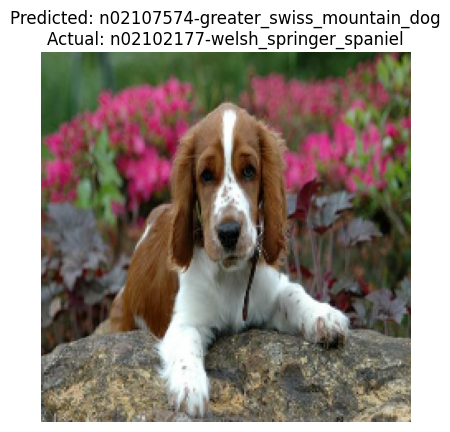

In [ ]:
for images, labels in ds_test.take(1):
    preds = model.predict(images)

    predicted_label = tf.argmax(preds[0]).numpy()
    true_label -= labels[0].numpy()

    predicted_breed = class_names[predicted_label]
    true_breed = class_names[true_label]

    plt.imshow(images[0])
    plt.axis("off")
    plt.title(f"Predicted: {predicted_breed}\nActual: {true_breed}")

    plt.show()